# **Импорт библиотек**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging
import time

from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from scipy import stats
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error, 
    r2_score, 
    mean_absolute_percentage_error
)

# **Определение функций**

## Функция загрузки данных

In [2]:
def load_data(cfg: dict):
    logger.info("Загрузка данных...")
    df = pd.read_csv(cfg["paths"]["trends"], parse_dates=['date'])
    meta = pd.read_csv(cfg["paths"]["metadata"], parse_dates=['created_at'])
    cols = meta.columns.difference(df.columns).tolist()
    df = df.merge(meta[['component_id'] + cols], on='component_id', how='left')

    df['closure_rate'] = round(df['closed_issues'] / (df['open_issues'] + df['closed_issues'] + 1e-8), 3)

    upper_bound = df['dependents'].quantile(0.98)
    df = df[df['dependents'] <= upper_bound]

    cols = ['downloads', 'future_downloads_3m', 'future_downloads_6m', 'future_downloads_12m']
    cols_df = np.log1p(df[cols])
    bounds = cols_df.quantile(0.998)
    mask = (cols_df <= bounds).all(axis=1)
    df = df[mask]

    df = df[df.groupby('component_id')['component_id'].transform('size') >= 24]

    df = df[[
        'component_id', 'date', 'future_downloads_3m', 'future_downloads_6m', 'future_downloads_12m',
        'type', 'language', 'category', 'license', 'author', 'ecosystem', 'status',
        'downloads', 'stars', 'contributors', 'dependencies', 'dependents', 'commits', 'releases', 'versions',
        'market_share', 'quality_score', 'documentation_score', 'community_score', 'maturity_score',
        'language_trend', 'category_trend', 'ecosystem_health', 'seasonality',
        'has_ci', 'has_examples', 'has_tests', 'has_tutorials', 'has_website',
        'open_issues', 'closed_issues', 'closure_rate'
    ]]
    
    return df

## Функция подготовки данных

In [3]:
def prepare_data(cfg: dict, df: pd.DataFrame):
    logger.info("Подготовка данных...")
    x = df.drop(columns=[
        "component_id", "date", "future_downloads_3m", "future_downloads_6m", "future_downloads_12m", "open_issues", "closed_issues"
    ])
    y = df[cfg["target"]]

    x_trainval, x_test, y_trainval, y_test = train_test_split(
        x, y, test_size=cfg["data"]["test_size"], random_state=cfg["random_seed"], shuffle=cfg["data"]["shuffle"]
    )

    x_train, x_val, y_train, y_val = train_test_split(
        x_trainval, y_trainval, test_size=cfg["data"]["val_size"], random_state=cfg["random_seed"], shuffle=cfg["data"]["shuffle"]
    )
    
    x_train["downloads"] = np.log1p(x_train["downloads"])
    x_test["downloads"] = np.log1p(x_test["downloads"])
    x_val["downloads"] = np.log1p(x_val["downloads"])
    y_train = np.log1p(y_train)
    y_test = np.log1p(y_test)
    y_val = np.log1p(y_val)
    
    return x_train, x_test, x_val, y_train, y_test, y_val

## Функция тренировки модели

In [4]:
def train_catboost(cfg: dict, x_train, x_val, y_train, y_val):
    logger.info("Запуск обучения CatBoost...")
    t0 = time.perf_counter()
    cat_feats = x_train.select_dtypes(exclude=['number', 'datetime']).columns.tolist()
    model = CatBoostRegressor(
        **cfg["model"],
        random_seed=cfg["random_seed"],
        cat_features=cat_feats,
        verbose=False
    )
    model.fit(x_train, y_train, eval_set=(x_val, y_val), early_stopping_rounds=50)
    train_time = time.perf_counter() - t0
    logger.info(f"Обучение завершено за {train_time:.3f} секунд")
    return model

## Функция для оценки важности признаков

In [5]:
def plot_feature_importance(model, X_train, top_n=15):
    importance = model.get_feature_importance()
    feature_names = X_train.columns.tolist()
    
    if len(importance) != len(feature_names):
        min_len = min(len(importance), len(feature_names))
        importance = importance[:min_len]
        feature_names = feature_names[:min_len]
        
    feat_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=True).tail(top_n)
    
    plt.figure(figsize=(12, 6))
    plt.barh(feat_imp['feature'], feat_imp['importance'], edgecolor='black')
    plt.xlabel('Важность (Gain)')
    plt.title(f'Топ {top_n} наиболее влияющих признаков')
    plt.grid(axis='x', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

## Функция оценки качества модели

In [6]:
def evaluate_model(model, x_test, y_test, true_y=False):
    y_pred = model.predict(x_test)
    if true_y:
        y_pred = np.expm1(y_pred)
        y_test = np.expm1(y_test)

    # ===== 1. ОСНОВНЫЕ МЕТРИКИ =====
    metrics = {
        'MSE': mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred) * 100,
        'R2': r2_score(y_test, y_pred),
        'Максимальная ошибка': np.max(np.abs(y_test - y_pred)),
        'Среднее предсказанное Y': np.mean(y_pred),
        'Среднее настоящее Y': np.mean(y_test),
        'Отклонение предсказанного Y': np.std(y_pred),
        'Отклонение настоящего Y': np.std(y_test),
    }

    # ===== 2. СТАТИСТИКА ОШИБОК =====
    residuals = y_test - y_pred
    error_stats = {
        'Средний остаток': np.mean(residuals),
        'Отклонение остатка': np.std(residuals),
        'Медиана остатка': np.median(residuals),
        'Residual остатков': stats.skew(residuals),
        'Kurtosis остатков': stats.kurtosis(residuals),
        'Минимальный остаток': np.min(residuals),
        'Максимальный остаток': np.max(residuals),
        '25%-й перцентиль остатка': np.percentile(residuals, 25),
        '75%-й перцентиль остатка': np.percentile(residuals, 75),
    }

    # ===== 3. МЕТРИКИ ПО КВАНТИЛЯМ =====
    quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
    quantile_metrics = {}
    for q in quantiles:
        q_val = np.quantile(y_test, q)
        mask = y_test <= q_val
        if mask.sum() > 0:
            quantile_metrics[f'Q{int(q*100)}_RMSE'] = np.sqrt(mean_squared_error(y_test[mask], y_pred[mask]))
            quantile_metrics[f'Q{int(q*100)}_MAE'] = mean_absolute_error(y_test[mask], y_pred[mask])
            quantile_metrics[f'Q{int(q*100)}_R2'] = r2_score(y_test[mask], y_pred[mask])

    # ===== 4. ГРАФИКИ =====
    fig, axes = plt.subplots(1, 4, figsize=(12, 3))

    # 4.1 Predicted vs Actual
    axes[0].scatter(y_test, y_pred, alpha=0.5, s=20)
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    axes[0].set_xlabel('Actual')
    axes[0].set_ylabel('Predicted')
    axes[0].set_title('Predicted vs Actual')

    # 4.2 Residuals vs Predicted
    axes[1].scatter(y_pred, residuals, alpha=0.5, s=20)
    axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('Residuals')
    axes[1].set_title('Residuals vs Predicted')

    # 4.3 Residuals Distribution
    axes[2].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    axes[2].axvline(x=0, color='r', linestyle='--', lw=2)
    axes[2].set_xlabel('Residual')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Residuals Distribution')

    # 4.4 Absolute Error Distribution
    abs_errors = np.abs(residuals)
    axes[3].hist(abs_errors, bins=50, edgecolor='black', alpha=0.7)
    axes[3].axvline(x=np.mean(abs_errors), color='r', linestyle='--', lw=2, label=f'Mean: {np.mean(abs_errors):.2f}')
    axes[3].set_xlabel('Absolute Error')
    axes[3].set_ylabel('Frequency')
    axes[3].set_title('Absolute Error Distribution')
    axes[3].legend()

    plt.tight_layout()
    plt.show()

    # ===== 5. ДОПОЛНИТЕЛЬНЫЕ ГРАФИКИ =====
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # 5.1 Residuals vs Each Feature (для первых 3 признаков)
    for idx, col in enumerate(x_test.columns[:3]):
        axes[idx].scatter(x_test[col], residuals, alpha=0.5, s=20)
        axes[idx].axhline(y=0, color='r', linestyle='--', lw=1)
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Residuals')
        axes[idx].set_title(f'Residuals vs {col}')
        axes[idx].tick_params(axis='x', labelrotation=90)

    plt.tight_layout()
    plt.show()

    print("=== ОСНОВНЫЕ МЕТРИКИ ===")
    for k, v in metrics.items():
        print(f"{k}: {v:.6f}")

    print("\n=== СТАТИСТИКА ОШИБОК ===")
    for k, v in error_stats.items():
        print(f"{k}: {v:.6f}")

    return residuals[np.abs(residuals) > 5000].index

## Функция для вывода информации о датафрейме

In [7]:
def data_info(df: pd.DataFrame, corr=0.7):
    display(pd.DataFrame({
            'Название столбца': df.columns,
            'Тип данных': df.dtypes.values,
            'Уникальных значений': [df[col].nunique() for col in df.columns],
            'Минимальное значение': [df[col].min() if pd.api.types.is_numeric_dtype(df[col]) else '---' for col in df.columns],
            'Максимальное значение': [df[col].max() if pd.api.types.is_numeric_dtype(df[col]) else '---' for col in df.columns],
            'Среднее значение': [df[col].mean() if pd.api.types.is_numeric_dtype(df[col]) else '---' for col in df.columns],
            'Медианное значение': [df[col].median() if pd.api.types.is_numeric_dtype(df[col]) else '---' for col in df.columns]
        }))
    print(f'Всего строк: {df.shape[0]} ({df.shape[0] / 24} компоненты)')

    # поиск коррелирующих пар
    numeric_df = df.select_dtypes(include=[np.number])
    corr_matrix = numeric_df.corr().abs()
    pairs = []
    columns = corr_matrix.columns
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            corr_val = corr_matrix.iloc[i, j]
            if corr_val >= corr:
                pairs.append({
                    'Признак 1': columns[i],
                    'Признак 2': columns[j],
                    'Корреляция': corr_val
                })
    if not pairs:
        print("Коррелирующих пар не найдено!")
    else:
        display(pd.DataFrame(pairs).sort_values('Корреляция', ascending=False))

## Функция для сохранения тестовой выборки

In [8]:
def test_to_csv(df, x_test):
    test_df = x_test.copy()
    test_df = test_df.drop(columns=["closure_rate"])
    test_df['downloads'] = df['downloads']
    test_df['future_downloads_3m'] = df['future_downloads_3m']
    test_df['future_downloads_6m'] = df['future_downloads_6m']
    test_df['future_downloads_12m'] = df['future_downloads_12m']

    open_issues = df.loc[test_df.index, 'open_issues']
    closed_issues = df.loc[test_df.index, 'closed_issues']
    test_df.insert(loc=15, column='open_issues', value=open_issues)
    test_df.insert(loc=16, column='closed_issues', value=closed_issues)

    test_df = test_df.reset_index(drop=True)
    test_df.to_csv("data/validation_set.csv", index=False)

# **Конфигурация**

In [9]:
CONFIG = {
    "random_seed": 42069,  # Фиксированное зерно для генератора случайных чисел
    "paths": {
        "trends": "data/component_trends_fixed.csv",      # Путь к файлу с временными рядами
        "metadata": "data/components_metadata_fixed.csv"  # Путь к файлу со статическими метаданными
    },
    "data": {
        "test_size": 0.2,   # Доля данных для финального теста
        "val_size": 0.3,    # Доля данных для валидации модели
        "shuffle": True     # Перемешивание данных перед разбиением
    },
    "target": "future_downloads_12m",  # Целевая переменная (target), которую мы предсказываем.
    "model": {
        "iterations": 1000,        # Максимальное количество деревьев (итераций бустинга)
        "learning_rate": 0.05,     # Темп обучения (шаг градиентного спуска)
        "depth": 10,               # Максимальная глубина деревьев
        "loss_function": "RMSE",   # Функция потерь, которую модель минимизирует (Root Mean Squared Error)
        "eval_metric": 'MAPE',     # Метрика для оценки на валидационной выборке (Mean Absolute Percentage Error)
        "l2_leaf_reg": 8,          # L2-регуляризация весов листьев
        "subsample": 0.8,          # Доля объектов обучающей выборки, случайно выбираемая для построения каждого дерева
        "colsample_bylevel": 0.8,  # Доля признаков, случайно выбираемая на каждом уровне дерева
        "min_data_in_leaf": 8,     # Минимальное количество объектов в листе дерева
        "max_ctr_complexity": 4,   # Максимальная сложность категориальных признаков
        "random_strength": 0.1     # Случайность при выборе порога разбиения
    }
}

# Настройка базового логгера для всей системы
logging.basicConfig(
    level=logging.INFO,  # Минимальный уровень важности сообщений (DEBUG, INFO, WARNING, ERROR, CRITICAL).
    format="%(asctime)s [%(levelname)s] %(message)s",  # Формат вывода: [Время] [Уровень] Текст сообщения.
)
logger = logging.getLogger("pipeline")

---
# **Эксперименты**

In [10]:
df = load_data(CONFIG)
x_train, x_test, x_val, y_train, y_test, y_val = prepare_data(CONFIG, df)
model = train_catboost(CONFIG, x_train, x_val, y_train, y_val)

2026-06-06 23:50:48,692 [INFO] Загрузка данных...
2026-06-06 23:50:49,108 [INFO] Подготовка данных...
2026-06-06 23:50:49,179 [INFO] Запуск обучения CatBoost...
2026-06-06 23:53:45,089 [INFO] Обучение завершено за 175.909 секунд


In [11]:
data_info(df)

,Название столбца,Тип данных,Уникальных значений,Минимальное значение,Максимальное значение,Среднее значение,Медианное значение
0,component_id,int64,454,1,500,250.612335,248.5
1,date,datetime64[us],24,---,---,---,---
2,future_downloads_3m,int64,2343,8,14800,732.321311,262.0
3,future_downloads_6m,int64,2248,8,14800,784.507801,280.0
4,future_downloads_12m,int64,1965,8,14800,832.15804,302.0
5,type,str,10,---,---,---,---
6,language,str,13,---,---,---,---
7,category,str,16,---,---,---,---
8,license,str,10,---,---,---,---
9,author,str,13,---,---,---,---


Всего строк: 10896 (454.0 компоненты)


,Признак 1,Признак 2,Корреляция
0,future_downloads_3m,future_downloads_6m,0.965892
9,open_issues,closed_issues,0.962977
2,future_downloads_3m,downloads,0.962501
6,stars,open_issues,0.943535
4,future_downloads_6m,downloads,0.927775
7,stars,closed_issues,0.907846
3,future_downloads_6m,future_downloads_12m,0.894567
5,future_downloads_12m,downloads,0.886120
1,future_downloads_3m,future_downloads_12m,0.872183
8,ecosystem_health,seasonality,0.701201


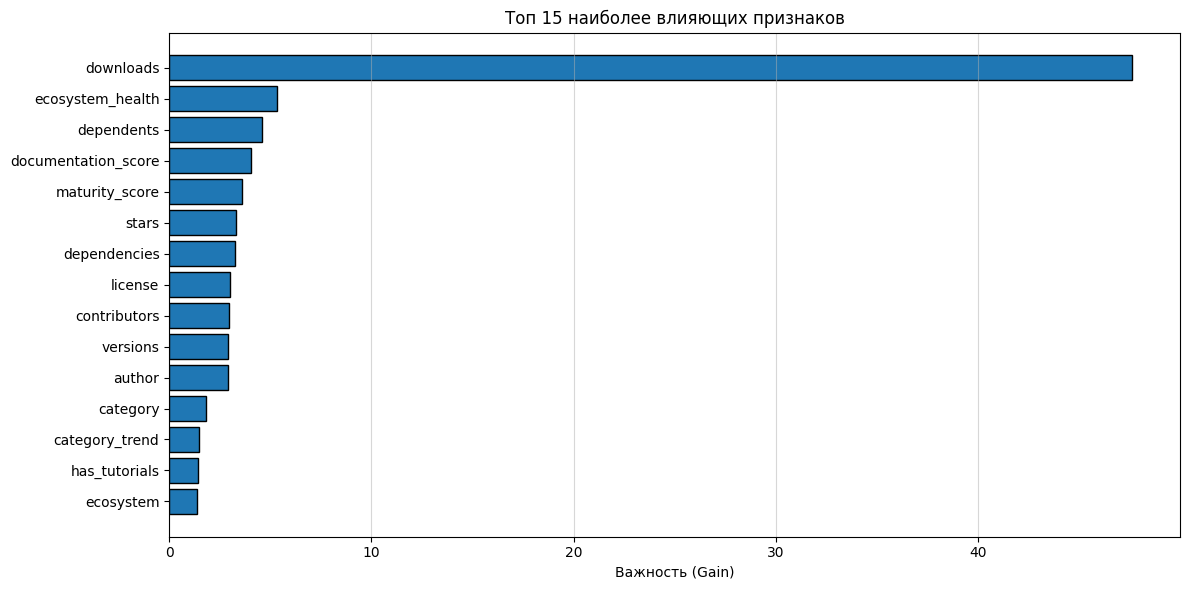

In [12]:
plot_feature_importance(model, x_train)

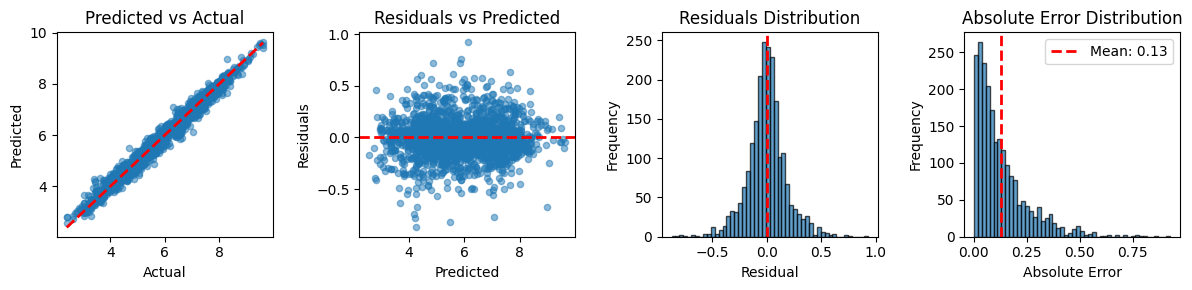

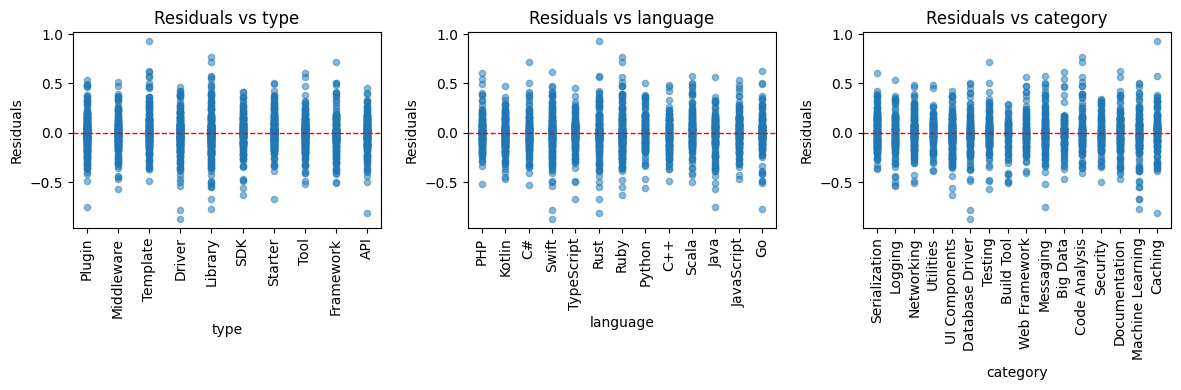

=== ОСНОВНЫЕ МЕТРИКИ ===
MSE: 0.031839
RMSE: 0.178436
MAE: 0.128238
MAPE: 2.371980
R2: 0.982490
Максимальная ошибка: 0.928006
Среднее предсказанное Y: 5.809595
Среднее настоящее Y: 5.808004
Отклонение предсказанного Y: 1.331748
Отклонение настоящего Y: 1.348445

=== СТАТИСТИКА ОШИБОК ===
Средний остаток: -0.001591
Отклонение остатка: 0.178429
Медиана остатка: -0.003621
Residual остатков: 0.025303
Kurtosis остатков: 2.328247
Минимальный остаток: -0.871751
Максимальный остаток: 0.928006
25%-й перцентиль остатка: -0.094530
75%-й перцентиль остатка: 0.084719


In [13]:
_ = evaluate_model(model, x_test, y_test)

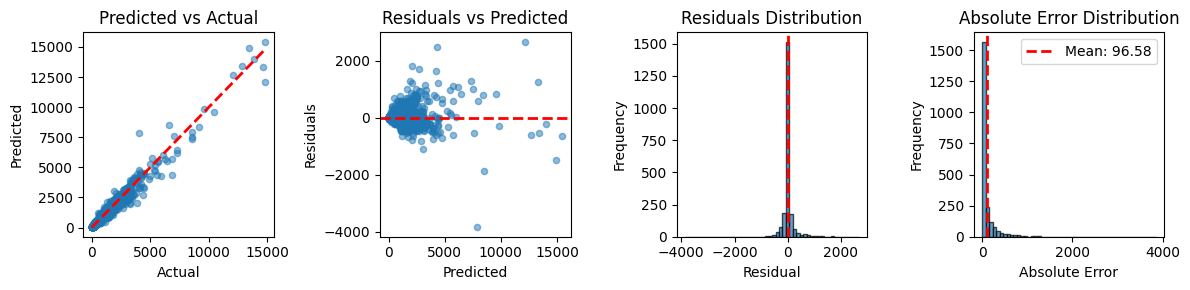

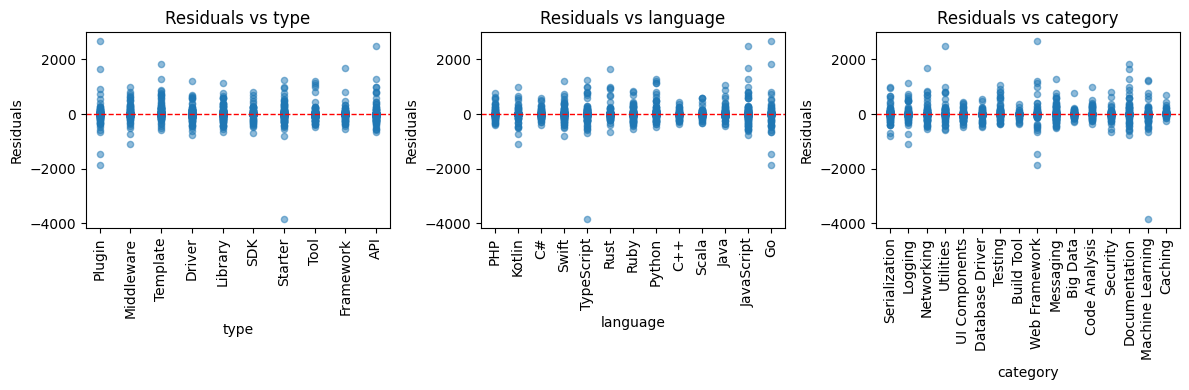

=== ОСНОВНЫЕ МЕТРИКИ ===
MSE: 53569.655293
RMSE: 231.451194
MAE: 96.583510
MAPE: 13.128090
R2: 0.968885
Максимальная ошибка: 3843.608411
Среднее предсказанное Y: 784.083925
Среднее настоящее Y: 796.256422
Отклонение предсказанного Y: 1281.165982
Отклонение настоящего Y: 1312.117648

=== СТАТИСТИКА ОШИБОК ===
Средний остаток: 12.172497
Отклонение остатка: 231.130884
Медиана остатка: -0.524600
Residual остатков: 0.247464
Kurtosis остатков: 59.832602
Минимальный остаток: -3843.608411
Максимальный остаток: 2667.802477
25%-й перцентиль остатка: -25.320268
75%-й перцентиль остатка: 24.455375


In [14]:
residuals = evaluate_model(model, x_test, y_test, true_y=True)

In [15]:
#model.save_model('models/catboost_12m.cbm')